# 03 - Application du Modèle de Motion Flow
Ce notebook charge un modèle de Motion Flow entraîné et l'applique à une image statique pour générer une vidéo ou un GIF animé.

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from scipy.ndimage import map_coordinates

# Ajouter le répertoire parent au path pour pouvoir importer depuis src
sys.path.append(os.path.abspath('..'))
from motion_flow.model import MotionFlowUNet
from IPython.display import Video, display, HTML


In [2]:
# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilisation du device: {device}")

Utilisation du device: cpu


In [3]:
import glob

TARGET_SIZE = 512

# Recherche automatique du dernier checkpoint
ckpt_dir = "../checkpoints"
CHECKPOINT_PATH = ""

if os.path.exists(ckpt_dir):
    runs = sorted(glob.glob(os.path.join(ckpt_dir, "run_*")), reverse=True) # On veut avoir le run le plus récent
    if runs:
        latest_run = runs[0]
        # On tente de charger model_best en priorité
        model_path = os.path.join(latest_run, "model_best.pth")
        if not os.path.exists(model_path):
            model_path = os.path.join(latest_run, "model_latest.pth")
            
        if os.path.exists(model_path):
            CHECKPOINT_PATH = model_path
            print(f"✓ Meilleur/Dernier modèle trouvé automatiquement : {CHECKPOINT_PATH}")
        else:
            print(f"⚠️ Aucun modèle .pth trouvé dans le run {latest_run}")
    else:
        print("⚠️ Aucun run trouvé dans checkpoints/")
else:
    print("⚠️ Dossier checkpoints/ introuvable")

if not CHECKPOINT_PATH:
    print("⚠️ Attention: Vous devez avoir un modèle entraîné pour que l'inférence soit pertinente !")


✓ Meilleur/Dernier modèle trouvé automatiquement : ../checkpoints/run_colab_3/model_best.pth


In [4]:
CHECKPOINT_PATH = "../checkpoints/epoch50/model_best.pth"

In [5]:
print(CHECKPOINT_PATH)

../checkpoints/epoch50/model_best.pth


In [6]:
# 1. Chargement du modèle
if CHECKPOINT_PATH and os.path.exists(CHECKPOINT_PATH):
    model = MotionFlowUNet().to(device)
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    model.eval()
    print("Modèle chargé et mis en mode évaluation.")
else:
    print("⚠️ Aucun checkpoint valide trouvé. Assurez-vous d'avoir entraîné le modèle avant de lancer l'inférence.")

Modèle chargé et mis en mode évaluation.


## 2. Chargement et Prétraitement de l'Image

Tirage aléatoire de l'image index: 62


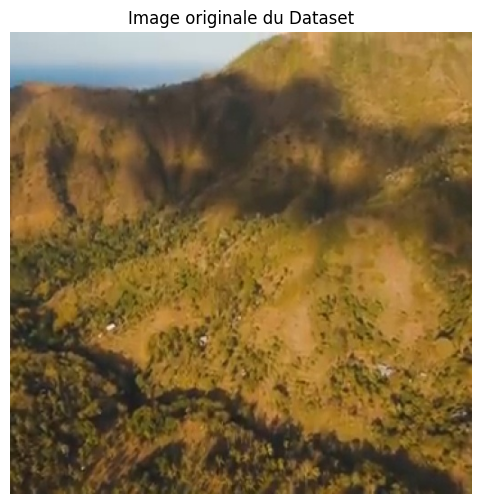

In [7]:
import random
from data.dataset import LandscapeMotionDataset

DATA_DIR = '../data/youtube_landscape'

# Fonction pour redimensionner au carré comme lors de l'entraînement
def preprocess_for_inference(img_array, target_size=512):
    h, w = img_array.shape[:2]
    # Resize
    if h < w:
        new_h = target_size
        new_w = int(w * (target_size / h))
    else:
        new_w = target_size
        new_h = int(h * (target_size / w))
    
    resized = cv2.resize(img_array, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Center Crop
    start_y = (new_h - target_size) // 2
    start_x = (new_w - target_size) // 2
    cropped = resized[start_y:start_y+target_size, start_x:start_x+target_size]
    
    # Normalisation entre 0 et 1 (comme transforms.ToTensor())
    tensor = torch.from_numpy(cropped).permute(2, 0, 1).float() / 255.0
    # Ajouter la dimension de batch: (1, C, H, W)
    return tensor.unsqueeze(0), cropped

try:
    dataset = LandscapeMotionDataset(DATA_DIR)
    if len(dataset) > 0:
        idx = random.randint(0, len(dataset) - 1)
        print(f"Tirage aléatoire de l'image index: {idx}")
        img_A, _ = dataset[idx]
        
        # Le dataset retourne déjà un Tensor (C, H, W) entre 0.0 et 1.0 (transforms.ToTensor())
        # on repasse en numpy pour le plot et on rajoute juste la dimension Batch
        input_tensor = img_A.unsqueeze(0).to(device)
        cropped_img = img_A.permute(1, 2, 0).numpy() # (H, W, C) pour plt
        
        plt.figure(figsize=(6, 6))
        plt.imshow(cropped_img)
        plt.title("Image originale du Dataset")
        plt.axis('off')
        plt.show()
    else:
        print("Dataset vide.")
except Exception as e:
    print(f"Erreur de chargement: {e}")

## 3. Prédiction du Mouvement (Inference)

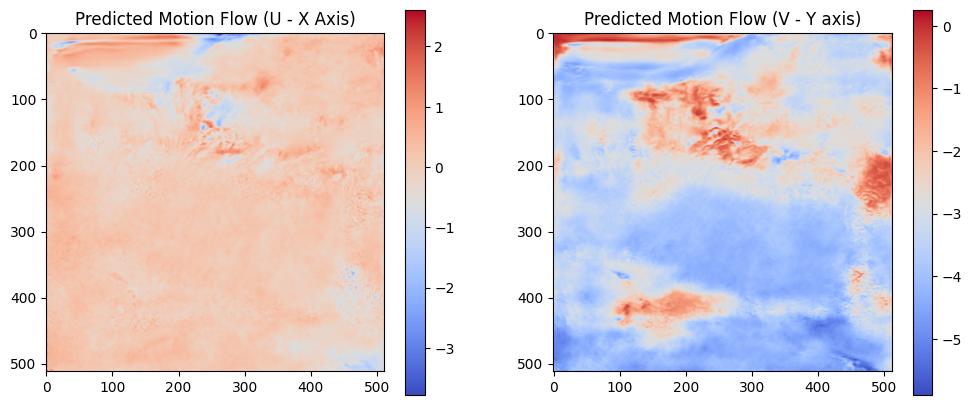

In [8]:
if 'model' in locals() and 'input_tensor' in locals():
    with torch.no_grad():
        # Notre modèle prédit un tenseur de mouvement (1, 2, H, W)
        pred_flow = model(input_tensor)
        
    flow = pred_flow.squeeze(0).cpu().numpy() # (2, H, W)
    flow_x = flow[0]
    flow_y = flow[1]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    im0 = axes[0].imshow(flow_x, cmap='coolwarm')
    axes[0].set_title("Predicted Motion Flow (U - X Axis)")
    fig.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(flow_y, cmap='coolwarm')
    axes[1].set_title("Predicted Motion Flow (V - Y axis)")
    fig.colorbar(im1, ax=axes[1])
    plt.show()

## 4. Animation (Warping)
On applique le flux à notre image pour synthétiser un mouvement, puis on sauve ce résultat en GIF.

In [9]:
if 'cropped_img' in locals() and 'flow_x' in locals():
    # PARAMETRES D'ANIMATION
    MOTION_MAGNITUDE = 25   # Intensite du mouvement (ex: 5 subtil, 20 fort)
    NUM_FRAMES = 60         # Nombre de frames totales
    FPS = 20                # Images par seconde
    PING_PONG = False        # True = Aller-retour fluide, False = Boucle simple
    
    h, w, c = cropped_img.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    video_path = '../data/animation.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    # Utiliser un bitrate élevé pour une meilleure qualité
    video_writer = cv2.VideoWriter(video_path, fourcc, float(FPS), (w, h))
    
    print(f"Génération de {NUM_FRAMES} frames...")
    
    for i in range(NUM_FRAMES):
        # Mouvement d'aller-retour fluide
        # Calcul de l'amplitude selon le type de boucle
        if PING_PONG:
            amplitude = np.sin((i / NUM_FRAMES) * 2 * np.pi)
        else:
            amplitude = i / NUM_FRAMES # 0 a 1
        
        # Mouvement accumulé (on amplifie l'effet)
        map_y = y - (flow_y * amplitude * MOTION_MAGNITUDE)
        map_x = x - (flow_x * amplitude * MOTION_MAGNITUDE)
        
        frame = np.zeros_like(cropped_img)
        
        for channel in range(c):
            frame[..., channel] = map_coordinates(
                cropped_img[..., channel], 
                [map_y, map_x], 
                order=1, 
                mode='reflect'
            )
        
        # Conversion en uint8 (0-255) pour OpenCV
        frame_uint8 = (np.clip(frame, 0, 1) * 255).astype(np.uint8)
        
        # OpenCV utilise BGR, donc on convertit de RGB
        frame_bgr = cv2.cvtColor(frame_uint8, cv2.COLOR_RGB2BGR)
        video_writer.write(frame_bgr)
        
    video_writer.release()
    print(f"Vidéo générée: {video_path}")
    
    # Conversion MP4 vers format compatible web (H264) pour affichage si nécessaire
    # (Souvent nécessaire sur certains navigateurs si 'mp4v' ne passe pas)
    os.system(f"ffmpeg -i {video_path} -vcodec libx264 -f mp4 -y {video_path.replace('.mp4', '_web.mp4')} -loglevel quiet")
    final_video = video_path.replace('.mp4', '_web.mp4')
    
    # Affichage
    from IPython.display import Video, display
    display(Video(final_video, embed=True, width=512, height=512))

Génération de 60 frames...
Vidéo générée: ../data/animation.mp4


## 6. Inférence Auto-Régressive (Expérimental)

In [11]:
# 6. Inférence Auto-Régressive (Expérimental)
# Cette méthode génère un mouvement continu en ré-injectant chaque nouvelle frame dans le modèle.
# ATTENTION : L'image peut devenir floue après plusieurs étapes à cause du ré-échantillonnage successif.

if 'model' in locals() and 'cropped_img' in locals():
    # PARAMETRES
    AR_STEPS = 30           # Nombre d'étapes de récursion
    AR_MAGNITUDE = 0.5      # Multiplicateur du mouvement à chaque étape
    AR_FPS = 10             # Vitesse de lecture
    
    current_img = cropped_img.copy() 
    ar_frames = []
    # On ajoute la frame initiale
    ar_frames.append(Image.fromarray((tmp_clip := np.clip(current_img, 0, 1) * 255).astype(np.uint8)))
    
    print(f'Lancement de l\'inférence auto-régressive ({AR_STEPS} étapes)...')
    
    h, w = current_img.shape[:2]
    y, x = np.mgrid[0:h, 0:w].astype(np.float32)
    
    for i in range(AR_STEPS):
        # 1. Préparation du tenseur pour le modèle
        input_tensor = torch.from_numpy(current_img).permute(2, 0, 1).float().unsqueeze(0).to(device)
        
        # 2. Prédiction du flow
        with torch.no_grad():
            flow_pred = model(input_tensor)
            if flow_pred.shape[2:] != (h, w):
                flow_pred = torch.nn.functional.interpolate(flow_pred, size=(h, w), mode='bilinear', align_corners=False)
            flow_np = flow_pred.squeeze(0).cpu().numpy()
        
        # 3. Application du mouvement (Warping)
        map_y = y - (flow_np[1] * AR_MAGNITUDE)
        map_x = x - (flow_np[0] * AR_MAGNITUDE)
        
        next_img = np.zeros_like(current_img)
        for channel in range(3):
            next_img[..., channel] = map_coordinates(
                current_img[..., channel], 
                [map_y, map_x], 
                order=1, 
                mode='reflect'
            )
        
        # 4. Mise à jour pour l'étape suivante
        current_img = np.clip(next_img, 0, 1)
        ar_frames.append(Image.fromarray((current_img * 255).astype(np.uint8)))
        
        if (i+1) % 10 == 0: print(f'Etape {i+1}/{AR_STEPS} terminée')
    
    # 5. Génération de la vidéo
    ar_video_path = 'autoregressive_animation.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(ar_video_path, fourcc, float(AR_FPS), (w, h))
    
    for frame in ar_frames:
        frame_bgr = cv2.cvtColor(np.array(frame), cv2.COLOR_RGB2BGR)
        video_writer.write(frame_bgr)
    video_writer.release()
    
    web_ar_video = 'autoregressive_animation_web.mp4'
    os.system(f'ffmpeg -i {ar_video_path} -vcodec libx264 -f mp4 -y {web_ar_video} -loglevel quiet')
    
    print(f'\nVidéo auto-régressive générée : {web_ar_video}')
    from IPython.display import Video, display
    display(Video(web_ar_video, embed=True, width=512, height=512))
else:
    print('❌ Modèle, image ou device non trouvés.\n'\
          f'Vérifiez que :\n'\
          f'1. Le modèle est chargé (Section 1)\n'\
          f'2. L\'image est prétraitée (Section 2)\n'\
          f'Variables présentes : model:{"model" in locals()}, cropped_img:{"cropped_img" in locals()}, device:{"device" in locals()}')


Lancement de l'inférence auto-régressive (30 étapes)...
Etape 10/30 terminée
Etape 20/30 terminée
Etape 30/30 terminée

Vidéo auto-régressive générée : autoregressive_animation_web.mp4
